# Richard Kwan
## Assignment 03, Problem 5

Fashion MNIST image classification with a PyTorch multilayer perceptron.

### Step 1: Data and runtime setup

Source: `scripts/01_train_classifier.py` and shared setup from `scripts/classifier_utils.py`.

In [1]:
from pathlib import Path
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
N_CLASSES = 10
N_EPOCHS = 20
BATCH_SIZE = 32
DATA_ROOT = Path("datasets")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / "image_classifier.pth"
HISTORY_PATH = ARTIFACTS_DIR / "training_history.json"
print(f"Using device: {DEVICE}")

transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root=str(DATA_ROOT), train=True, download=True, transform=transform
)
test_data = torchvision.datasets.FashionMNIST(
    root=str(DATA_ROOT), train=False, download=True, transform=transform
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

X_sample, y_sample = train_data[0]
print(f"Sample shape: {tuple(X_sample.shape)}, dtype: {X_sample.dtype}")
print(f"Sample class: {train_and_valid_data.classes[y_sample]}")

Using device: cpu
Sample shape: (1, 28, 28), dtype: torch.float32
Sample class: Ankle boot


### Step 2: Classifier and training helpers

Source: shared model and `train2` / `evaluate_tm` helpers in `scripts/classifier_utils.py`.

In [2]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=784, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, X):
        return self.mlp(X)


def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item()
        )
        print(
            f"Epoch {epoch + 1}/{n_epochs}, "
            f"train loss: {history['train_losses'][-1]:.4f}, "
            f"train metric: {history['train_metrics'][-1]:.4f}, "
            f"valid metric: {history['valid_metrics'][-1]:.4f}"
        )
    return history

### Step 3: Train for 20 epochs

Source: `scripts/01_train_classifier.py`. This records both accuracies each epoch and saves reusable weights and history.

In [3]:
torch.manual_seed(42)
model = ImageClassifier().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=N_CLASSES).to(DEVICE)
history = train2(
    model, optimizer, criterion, accuracy, train_loader, valid_loader, N_EPOCHS
)
torch.save(model.state_dict(), MODEL_PATH)
with HISTORY_PATH.open("w", encoding="utf-8") as history_file:
    json.dump(history, history_file, indent=2)
print(f"Saved model weights to {MODEL_PATH}")
print(f"Saved training history to {HISTORY_PATH}")

Epoch 1/20, train loss: 0.6062, train metric: 0.7809, valid metric: 0.8430


Epoch 2/20, train loss: 0.4064, train metric: 0.8497, valid metric: 0.8420


Epoch 3/20, train loss: 0.3634, train metric: 0.8660, valid metric: 0.8636


Epoch 4/20, train loss: 0.3354, train metric: 0.8763, valid metric: 0.8654


Epoch 5/20, train loss: 0.3142, train metric: 0.8842, valid metric: 0.8778


...

Epoch 16/20, train loss: 0.2087, train metric: 0.9206, valid metric: 0.8752


Epoch 17/20, train loss: 0.2043, train metric: 0.9213, valid metric: 0.8814


Epoch 18/20, train loss: 0.1996, train metric: 0.9236, valid metric: 0.8864


Epoch 19/20, train loss: 0.1936, train metric: 0.9268, valid metric: 0.8844


Epoch 20/20, train loss: 0.1880, train metric: 0.9285, valid metric: 0.8700
Saved model weights to artifacts\image_classifier.pth
Saved training history to artifacts\training_history.json


### Step 4: Predict on three validation images

Source: `scripts/02_predict_validation.py`. Probabilities are computed with softmax and the four most likely classes are displayed for each image.

In [4]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
X_batch, y_batch = next(iter(valid_loader))
X_new = X_batch[:3].to(DEVICE)
y_true = y_batch[:3]
with torch.no_grad():
    probabilities = F.softmax(model(X_new), dim=1)
    top_probabilities, top_classes = probabilities.topk(4, dim=1)

for image_index, (class_indices, class_probabilities) in enumerate(
    zip(top_classes.cpu(), top_probabilities.cpu()), start=1
):
    actual_class = train_and_valid_data.classes[y_true[image_index - 1]]
    print(f"Image {image_index}: actual={actual_class}")
    for class_index, probability in zip(class_indices, class_probabilities):
        class_name = train_and_valid_data.classes[class_index.item()]
        print(f"  {class_name}: {probability.item():.4f}")

Image 1: actual=Sneaker
  Sneaker: 0.8904
  Ankle boot: 0.1075
  Sandal: 0.0016
  Bag: 0.0002
Image 2: actual=Coat
  Coat: 0.9968
  Pullover: 0.0031
  Shirt: 0.0001
  T-shirt/top: 0.0000
Image 3: actual=Pullover
  Pullover: 0.5452
  Coat: 0.2390
  Shirt: 0.2050
  T-shirt/top: 0.0043


### Step 5: Count model parameters

Source: `scripts/03_count_parameters.py`.

In [5]:
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {parameter_count:,}")

Trainable parameters: 266,610


### Step 6: Plot training and validation accuracy

Source: `scripts/04_plot_training_accuracy.py`. The figure is saved as `training_accuracy.png`.

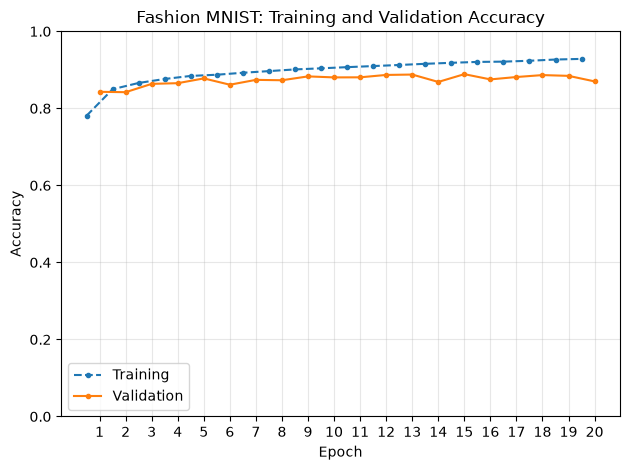

In [6]:
epochs = len(history["train_metrics"])
plt.plot(
    [epoch + 0.5 for epoch in range(epochs)],
    history["train_metrics"],
    ".--",
    label="Training",
)
plt.plot(
    [epoch + 1.0 for epoch in range(epochs)],
    history["valid_metrics"],
    ".-",
    label="Validation",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fashion MNIST: Training and Validation Accuracy")
plt.xticks(range(1, epochs + 1))
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("training_accuracy.png", dpi=150)
plt.show()